In [1]:

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!curl -L "https://universe.roboflow.com/ds/glquRaJDf9?key=1kWinBXVTQ" > roboflow.zip; unzip roboflow.zip; rm roboflow.zip

Streaming output truncated to the last 5000 lines.
  inflating: train/labels/001677_JPG_jpg.rf.414e120831f7e7f30447cb3cb26bdc83.txt  
 extracting: train/labels/001677_JPG_jpg.rf.d0e22a225cbb317066ae2e6efd3dbcc2.txt  
  inflating: train/labels/001678_JPG_jpg.rf.21782caf845bde6574cb51b3f5c74490.txt  
  inflating: train/labels/001678_JPG_jpg.rf.4de99d4836e879bc0a6b13d15eefe346.txt  
  inflating: train/labels/001678_JPG_jpg.rf.d9b987c7dd66459a58b74d90a6970de7.txt  
  inflating: train/labels/001679_JPG_jpg.rf.7f8083798d74d6e40543f776ec116c6a.txt  
  inflating: train/labels/001679_JPG_jpg.rf.c11f3850b8f5630a0b21810e0a256c90.txt  
  inflating: train/labels/001679_JPG_jpg.rf.f0cdb80eb57c2cf67c5306cbf7c19aac.txt  
  inflating: train/labels/001680_JPG_jpg.rf.05690ffb9e45dcb471a95f0b96806331.txt  
  inflating: train/labels/001680_JPG_jpg.rf.8472e670be11dc0438f4a3e001e124bb.txt  
  inflating: train/labels/001680_JPG_jpg.rf.fc6132ab57b715e2192ea08bbc90067d.txt  
  inflating: train/labels/001681_JPG

In [3]:
!cp -r /content/drive/MyDrive/yolo/PGD_augmented_images.zip /content/
!unzip -q PGD_augmented_images.zip
!cp -r /content/drive/MyDrive/yolo/fgsm_augmented_images.zip /content/
!unzip -q fgsm_augmented_images.zip
!cp -r /content/drive/MyDrive/yolo/uap_augmented_images.zip /content/
!unzip -q uap_augmented_images.zip
!cp -r /content/drive/MyDrive/yolo/Tdag_augmented_images.zip /content/
!unzip -q Tdag_augmented_images.zip

In [41]:
# prompt: merge the contents of  ['/content/content/PGD_augmented_images/images', '/content/content/fgsm_augmented_images/images', '/content/content/uap_augmented_images/images', '/content/content/Tdag_augmented_images/images','fool_augmented_images/images'] to /content/adversarial_images/images and  the contents of  ['/content/content/PGD_augmented_images/labels', '/content/content/fgsm_augmented_images/labels', '/content/content/uap_augmented_images/labels', '/content/content/labels/images','fool_augmented_images/images'] to /content/adversarial_images/labels

import shutil
import os

# Create the destination directories if they don't exist
os.makedirs("/content/adversarial_images/images", exist_ok=True)
os.makedirs("/content/adversarial_images/labels", exist_ok=True)

source_image_dirs = [
    '/content/content/PGD_augmented_images/images',
    '/content/content/fgsm_augmented_images/images',
    '/content/content/uap_augmented_images/images',
    '/content/content/Tdag_augmented_images/images',
    'fool_augmented_images/images'  # Assuming this path is correct relative to the notebook
]

source_label_dirs = [
    '/content/content/PGD_augmented_images/labels',
    '/content/content/fgsm_augmented_images/labels',
    '/content/content/uap_augmented_images/labels',
    '/content/content/labels/labels', # Assuming this path is correct relative to the notebook
    'fool_augmented_images/labels'  # Assuming this path is correct relative to the notebook
]

# Merge images
for source_dir in source_image_dirs:
  if os.path.exists(source_dir):
    for filename in os.listdir(source_dir):
      source_path = os.path.join(source_dir, filename)
      destination_path = os.path.join("/content/adversarial_images/images", filename)
      if os.path.isfile(source_path):
        shutil.copy2(source_path, destination_path) # copy2 preserves metadata

# Merge labels
for source_dir in source_label_dirs:
  if os.path.exists(source_dir):
    for filename in os.listdir(source_dir):
      source_path = os.path.join(source_dir, filename)
      destination_path = os.path.join("/content/adversarial_images/labels", filename)
      if os.path.isfile(source_path):
        shutil.copy2(source_path, destination_path) # copy2 preserves metadata


In [42]:
# prompt: count /content/adversarial_images/images/*.png

import os
image_count = 0
for filename in os.listdir('/content/adversarial_images/images'):
    if filename.endswith('.png'):
        image_count +=1
print(f"The number of png images is: {image_count}")


The number of png images is: 6982


In [66]:
import os
import random

# Directories
image_dir = "/content/train/images"
label_dir = "/content/train/labels"
adversarial_dir = "/content/adversarial_images"

# Prefixes of adversarial images to exclude
adversarial_prefixes = ['adv_fgsm_', 'adv_dag_', 'adv_uap_', 'adv_pgd_','adv_fool_']

# Get list of adversarial image names
adversarial_images = os.listdir(adversarial_dir)

# Extract original image names from adversarial images
original_from_adversarial = set()
for adv_image in adversarial_images:
    for prefix in adversarial_prefixes:
        if adv_image.startswith(prefix):
            original_name = adv_image[len(prefix):].replace('.png', '.jpg')  # Convert to .jpg
            original_from_adversarial.add(original_name)
            break

# Get all .jpg images from the original image directory and verify existence
all_images = [f for f in os.listdir(image_dir) if f.endswith('.jpg') and os.path.isfile(os.path.join(image_dir, f))]

# Filter out images that are in the adversarial set
valid_images = [img for img in all_images if img not in original_from_adversarial]

# Randomly select 1500 images
selected_images = random.sample(valid_images, min(1500, len(valid_images)))

# Get corresponding label files (assuming labels have same name but .txt extension)
selected_labels = []
for img in selected_images:
    label_name = os.path.splitext(img)[0] + '.txt'
    label_path = os.path.join(label_dir, label_name)
    if os.path.isfile(label_path):
        selected_labels.append(label_name)
    else:
        print(f"Warning: Label file for {img} not found at {label_path}")

# Print results
print(f"Selected Images: {len(selected_images)}")
print(selected_images)
print(f"Selected Labels: {len(selected_labels)}")
print(selected_labels)

Selected Images: 1500
['001239_jpg.rf.695302727400bb4b2324a29dd589c721.jpg', '000942_JPG_jpg.rf.5f1edd207f813d17cb8c82dde069e61f.jpg', '00000_00002_00011_png.rf.10d9472b901c58ea84b06fb8f2052742.jpg', '000571_jpg.rf.7642c3bec936bf92f3c88b27d0964a83.jpg', '00004_00015_00008_png.rf.623e88ef5a067e2ddf1c4f99deca751f.jpg', 'FisheyeCamera_1_00126_png.rf.a2692a170c1f5251d61d94d106a39fad.jpg', '00001_00017_00023_png.rf.e6bd2dd59c446bcaf6b5c3812d203777.jpg', '000591_jpg.rf.ca719501138027f1ed8a6b0aaa2e04ea.jpg', 'road61_png.rf.331ef6956481984a9c6ce787a55e0797.jpg', '00002_00029_00019_png.rf.cedc594c150fd4f78489f009df11e4d3.jpg', '000577_jpg.rf.fd543887ed8746ecf6cf944c5df1e83e.jpg', '000301_jpg.rf.666e9f9858416d5e036539ac082c7405.jpg', '00000_00000_00015_png.rf.ad65dcee013d097499b65d28e12e9fb5.jpg', '000428_jpg.rf.5ac0c85eaa34dc6ab4ccaec9903d9ceb.jpg', '00000_00001_00000_png.rf.7b1348bb8f7668873301e49190206ff0.jpg', '000322_jpg.rf.557a3b4f5281227858de1e1b217ff553.jpg', '00003_00027_00026_png.rf.24

In [8]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 101.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 80.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 99.3 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling

In [67]:
from attacks import fool_detectors_attack,fgsm_attack_detector
import os
import torch
import numpy as np
from sklearn.cluster import KMeans
from torchvision import models, transforms
from PIL import Image
from util import preprocess_image, compare_original_and_adversarial_png
import torch
from ultralytics import YOLO


In [68]:
import sys
import io
class SuppressPrints:  # Context manager to silence function output
    def __enter__(self):
        self._original_stdout = sys.stdout
        sys.stdout = io.StringIO()
    def __exit__(self, exc_type, exc_val, exc_tb):
        sys.stdout = self._original_stdout

In [69]:
model_path = "/content/drive/MyDrive/yolo/yolov8n_TrafficSigns.pt"
model = YOLO(model_path)

In [70]:
import os
import torch
from torchvision.utils import save_image
from pathlib import Path
import shutil

# Output directories
output_image_dir = Path("fgsm2_augmented_images/images")
output_label_dir = Path("fgsm2_augmented_images/labels")
output_image_dir.mkdir(parents=True, exist_ok=True)
output_label_dir.mkdir(parents=True, exist_ok=True)


# Filter valid image-label pairs
paired_data = []
for img_name, lbl_name in zip(selected_images, selected_labels):
    img_path = os.path.join(image_dir, img_name)
    lbl_path = os.path.join(label_dir, lbl_name)
    if os.path.isfile(img_path) and os.path.isfile(lbl_path):
        paired_data.append((img_name, lbl_name))
    else:
        print(f"Skipping {img_name}: Image or label file missing")


# Attack loop
i = 0
for img_name, label_name in paired_data:
    try:
        # Construct full paths
        img_path = Path(image_dir) / img_name
        label_path = Path(label_dir) / label_name

        # Verify image exists
        if not img_path.is_file():
            print(f"Skipping {img_name}: Image file not found at {img_path}")
            continue

        # Run model inference
        results = model(str(img_path))
        detected_classes = results[0].boxes.cls.int().tolist()

        # Generate adversarial image
        with SuppressPrints():
            adv_tensor = fgsm_attack_detector(
            image_path=str(img_path),
            model_path=model_path,
            epsilon=0.1,
            conf_threshold=0.25,
            device="cuda" if torch.cuda.is_available() else "cpu"
        )

        # Skip if attack failed
        if adv_tensor is None:
            print(f"Skipping {img_name}: Adversarial attack failed")
            continue

        # Save adversarial image and copy label
        base_name = f"adv_fgsm_{img_path.stem}"
        adv_image_path = output_image_dir / f"{base_name}.png"  # Match original .jpg extension
        adv_label_path = output_label_dir / f"{base_name}.txt"

        save_image(adv_tensor.clone().detach().cpu(), str(adv_image_path), normalize=True)
        shutil.copy(str(label_path), str(adv_label_path))

        i += 1
        if i % 10 == 0:
            print("-----------------------------------")
            print()
            print()
            print(f"Generated {i} adversarial examples.")
            print()
            print()
            print("-----------------------------------")

        # Clear GPU memory (if using CUDA)
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    except Exception as e:
        print(f"Error processing {img_name}: {e}")
        continue

print(f"Total adversarial examples generated: {i}")

Streaming output truncated to the last 5000 lines.
Speed: 2.4ms preprocess, 11.0ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)
-----------------------------------


Generated 150 adversarial examples.


-----------------------------------

image 1/1 /content/train/images/001011_jpg.rf.d0e7534f697396dac78bed1713ff0328.jpg: 640x640 1 Speed Limit 100, 8.8ms
Speed: 2.3ms preprocess, 8.8ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/train/images/001218_jpg.rf.145c3bfff6ce2df4ba9c5fc2d86de1db.jpg: 640x640 1 Speed Limit 110, 2 Speed Limit 80s, 8.7ms
Speed: 2.4ms preprocess, 8.7ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/train/images/000666_jpg.rf.a91e3b2f6913a09bf4a1e67c20377bdb.jpg: 640x640 1 Speed Limit 80, 8.9ms
Speed: 2.4ms preprocess, 8.9ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/train/images/000519_jpg.rf.418b8b935384805e19105c3d6a3d7592.

In [71]:
# prompt: zip fgsm2_augmented_images

from pathlib import Path

# Define the directory to zip
directory_to_zip = Path("fgsm2_augmented_images")

# Create the zip file
!zip -r fgsm2_augmented_images.zip {directory_to_zip}


  adding: fgsm2_augmented_images/ (stored 0%)
  adding: fgsm2_augmented_images/images/ (stored 0%)
  adding: fgsm2_augmented_images/images/adv_fgsm_road870_png.rf.e1734b0a288760e2e85a2878de8ffef8.png (deflated 0%)
  adding: fgsm2_augmented_images/images/adv_fgsm_FisheyeCamera_1_00455_png.rf.0d78212756fdf6318eea7ead90988e86.png (deflated 0%)
  adding: fgsm2_augmented_images/images/adv_fgsm_000072_jpg.rf.7bf654e3ca1dbb7e7ae9b9ad2bfa5274.png (deflated 0%)
  adding: fgsm2_augmented_images/images/adv_fgsm_001811_JPG_jpg.rf.5f73381de12dc1424678edd456b23f3f.png (deflated 0%)
  adding: fgsm2_augmented_images/images/adv_fgsm_001476_jpg.rf.b1769d58cb5ccf641e946b2d3b156c22.png (deflated 0%)
  adding: fgsm2_augmented_images/images/adv_fgsm_00002_00004_00007_png.rf.f993b71d5d98fa6b376c08239a382e63.png (deflated 0%)
  adding: fgsm2_augmented_images/images/adv_fgsm_FisheyeCamera_1_00018_png.rf.1b55371d011561dc137374e191245494.png (deflated 0%)
  adding: fgsm2_augmented_images/images/adv_fgsm_00014_00

Found 6982 adversarial images (.png).
Retrieved 6982 original images (.jpg).
Displaying 5 image pairs.


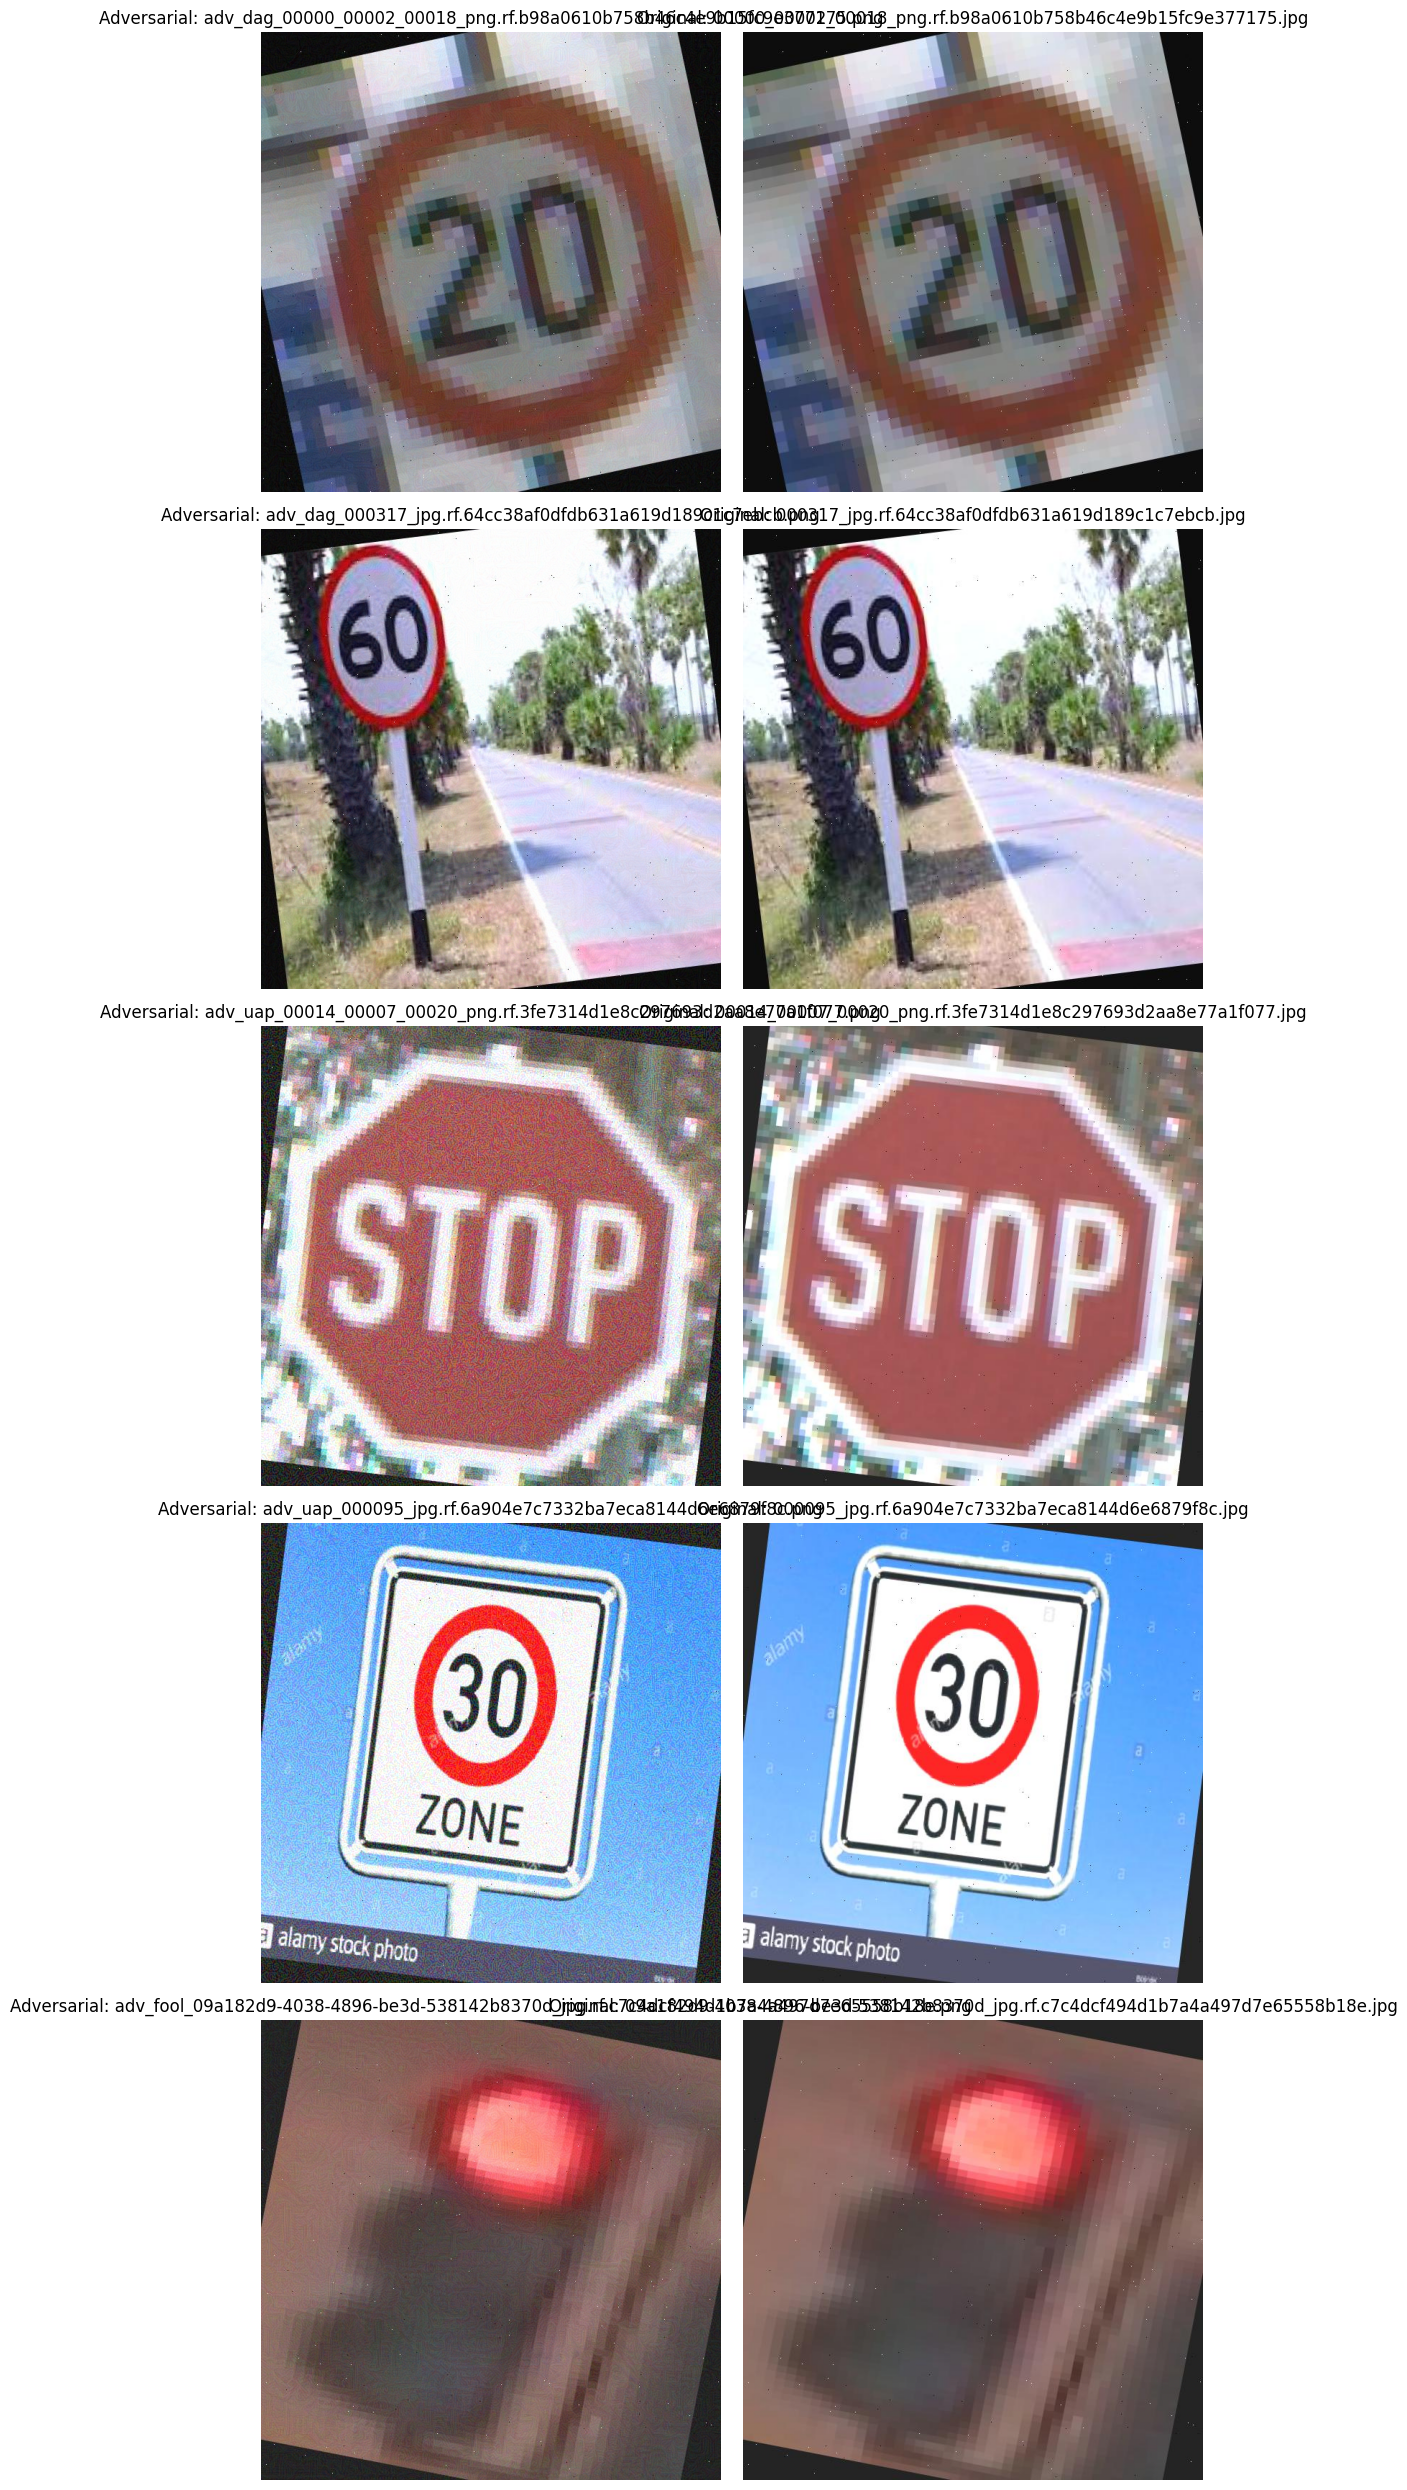

In [53]:
import os
from pathlib import Path
import shutil

import matplotlib.pyplot as plt
from PIL import Image

def display_image_pairs(adversarial_paths, original_paths, num_pairs=5):
    """
    Display pairs of adversarial and original images side by side.

    Args:
        adversarial_paths (list): List of adversarial image paths (.png).
        original_paths (list): List of corresponding original image paths (.jpg).
        num_pairs (int): Number of pairs to display.
    """
    # Limit the number of pairs to display
    num_pairs = min(num_pairs, len(adversarial_paths))
    if num_pairs == 0:
        print("No image pairs to display.")
        return

    # Set up the plot
    fig, axes = plt.subplots(num_pairs, 2, figsize=(10, 5 * num_pairs))
    if num_pairs == 1:
        axes = [axes]  # Ensure axes is iterable for a single pair

    for i in range(num_pairs):
        # Load adversarial and original images
        try:
            adv_img = Image.open(adversarial_paths[i])
            orig_img = Image.open(original_paths[i])

            # Display adversarial image
            axes[i][0].imshow(adv_img)
            axes[i][0].set_title(f"Adversarial: {Path(adversarial_paths[i]).name}")
            axes[i][0].axis('off')

            # Display original image
            axes[i][1].imshow(orig_img)
            axes[i][1].set_title(f"Original: {Path(original_paths[i]).name}")
            axes[i][1].axis('off')

        except Exception as e:
            print(f"Error displaying pair {adversarial_paths[i]} and {original_paths[i]}: {e}")

    plt.tight_layout()
    plt.show()



def retrieve_original_images(adversarial_dir, original_dir, output_dir=None, display_num=5):
    """
    Retrieve original .jpg images corresponding to adversarial .png images by removing prefixes
    and converting extensions. Optionally display some pairs.

    Args:
        adversarial_dir (str): Directory containing adversarial images (e.g., adv_fgsm_image123.png).
        original_dir (str): Directory containing original images (e.g., image123.jpg).
        output_dir (str, optional): Directory to save retrieved original images. If None, only prints paths.
        display_num (int): Number of image pairs to display for verification.

    Returns:
        tuple: (list of adversarial paths, list of original paths) for the retrieved pairs.
    """
    # Convert directories to Path objects
    adversarial_dir = Path(adversarial_dir)
    original_dir = Path(original_dir)
    if output_dir:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)

    # Define adversarial prefixes
    prefixes = ['adv_fgsm_', 'adv_dag_', 'adv_uap_', 'adv_pgd_','adv_fool_']

    # List adversarial images (.png)
    adversarial_files = [f for f in adversarial_dir.glob("*.png") if f.is_file()]
    print(f"Found {len(adversarial_files)} adversarial images (.png).")

    # Store paths to adversarial and original images
    adversarial_image_paths = []
    original_image_paths = []
    missing_images = []

    # Process each adversarial image
    for adv_file in adversarial_files:
        adv_name = adv_file.name
        # Remove adversarial prefix
        original_name = None
        for prefix in prefixes:
            if adv_name.startswith(prefix):
                original_name = adv_name[len(prefix):]
                break

        if original_name:
            # Replace .png with .jpg to match original image extension
            original_name = original_name.replace('.png', '.jpg')
            # Construct path to original image
            original_path = original_dir / original_name
            if original_path.exists():
                adversarial_image_paths.append(str(adv_file))
                original_image_paths.append(str(original_path))
                # Optionally copy to output directory
                if output_dir:
                    shutil.copy(original_path, output_dir / original_name)
            else:
                missing_images.append(original_name)
                print(f"Original image not found: {original_name}")
        else:
            print(f"No valid prefix found in adversarial image: {adv_name}")

    print(f"Retrieved {len(original_image_paths)} original images (.jpg).")
    if missing_images:
        print(f"Missing {len(missing_images)} original images: {missing_images[:5]} (showing first 5 if many).")

    # Display a few pairs for verification
    if display_num > 0 and original_image_paths:
        print(f"Displaying {min(display_num, len(original_image_paths))} image pairs.")
        display_image_pairs(adversarial_image_paths, original_image_paths, num_pairs=display_num)

    return adversarial_image_paths, original_image_paths


# Example usage
adversarial_dir = "/content/adversarial_images/images"  # Replace with your adversarial images directory
original_dir = "/content/train/images"           # Replace with your original dataset directory
output_dir = "/content/original_images"      # Optional: where to save retrieved images

display_num = 5                                  # Number of pairs to display

adv_paths, orig_paths = retrieve_original_images(adversarial_dir, original_dir, output_dir, display_num)


In [46]:
!pip install torch torchvision tqdm

import os
import glob
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tqdm import tqdm
import matplotlib.pyplot as plt

# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

In [47]:
class ImageDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        img = Image.open(img_path).convert('RGB')

        if self.transform:
            img = self.transform(img)

        return img, label

# Define transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # MobileNetV2 expects 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet normalization
])


In [59]:
def load_dataset(clean_dir='/content/original_images', adv_dir='/content/adversarial_images/images'):
    clean_images = glob.glob(os.path.join(clean_dir, '*.jpg'))
    adv_images = glob.glob(os.path.join(adv_dir, '*.png'))

    # Labels: 0 for clean, 1 for adversarial
    clean_labels = [0] * len(clean_images)
    adv_labels = [1] * len(adv_images)

    # Combine
    all_images = clean_images + adv_images
    all_labels = clean_labels + adv_labels
    print(f"Clean images: {len(clean_images)}, Adversarial images: {len(adv_images)}")
    print(f"Dataset: {len(all_images)} images")

    # Shuffle and split: 70% train, 15% val, 15% test
    train_images, temp_images, train_labels, temp_labels = train_test_split(
        all_images, all_labels, test_size=0.15, random_state=42, stratify=all_labels
    )
    val_images, test_images, val_labels, test_labels = train_test_split(
        temp_images, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels
    )

    print(f"Dataset: {len(train_images)} train, {len(val_images)} val, {len(test_images)} test")
    return (train_images, train_labels), (val_images, val_labels), (test_images, test_labels)

# Load dataset
(train_images, train_labels), (val_images, val_labels), (test_images, test_labels) = load_dataset()

# Create datasets
train_dataset = ImageDataset(train_images, train_labels, transform=transform)
val_dataset = ImageDataset(val_images, val_labels, transform=transform)
test_dataset = ImageDataset(test_images, test_labels, transform=transform)

# Create data loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)


Clean images: 6205, Adversarial images: 6982
Dataset: 13187 images
Dataset: 11208 train, 989 val, 990 test


In [60]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load MobileNetV2 with pre-trained weights
model = models.mobilenet_v2(pretrained=True)

# Modify the classifier for binary classification
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)  # 2 classes: clean, adversarial
model = model.to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


Using device: cuda


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/10: 100%|██████████| 351/351 [02:45<00:00,  2.12it/s]


Epoch 1/10:
Train Loss: 0.1224, Val Loss: 0.0551, Val Accuracy: 0.9788
Saved best model with Val Loss: 0.0551


Epoch 2/10: 100%|██████████| 351/351 [02:42<00:00,  2.16it/s]


Epoch 2/10:
Train Loss: 0.0513, Val Loss: 0.0608, Val Accuracy: 0.9818
Patience counter: 1/2


Epoch 3/10: 100%|██████████| 351/351 [02:38<00:00,  2.22it/s]


...

Epoch 8/10:
Train Loss: 0.0207, Val Loss: 0.0044, Val Accuracy: 0.9980
Saved best model with Val Loss: 0.0044


Epoch 9/10: 100%|██████████| 351/351 [03:03<00:00,  1.91it/s]


Epoch 9/10:
Train Loss: 0.0155, Val Loss: 0.4923, Val Accuracy: 0.7624
Patience counter: 1/2


Epoch 10/10: 100%|██████████| 351/351 [02:33<00:00,  2.29it/s]


Epoch 10/10:
Train Loss: 0.0195, Val Loss: 0.0587, Val Accuracy: 0.9838
Patience counter: 2/2
Early stopping triggered after epoch 10
Loaded best model from /content/classifier_mobilenetv2_best.pth


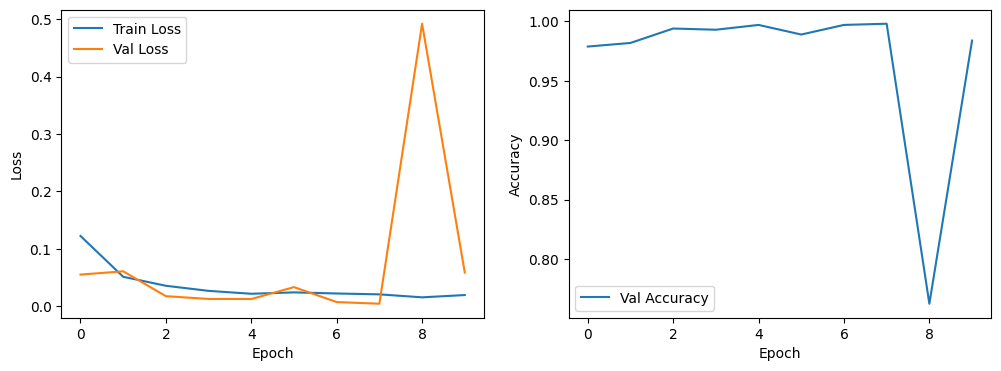

In [61]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10, patience=2):
    train_losses = []
    val_losses = []
    val_accuracies = []

    best_val_loss = float('inf')
    best_model_path = '/content/classifier_mobilenetv2_best.pth'
    patience_counter = 0

    for epoch in range(num_epochs):
        # Training
        model.train()
        running_loss = 0.0
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

        epoch_train_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        # Validation
        model.eval()
        val_loss = 0.0
        preds, true_labels = [], []
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)

                _, predicted = torch.max(outputs, 1)
                preds.extend(predicted.cpu().numpy())
                true_labels.extend(labels.cpu().numpy())

        epoch_val_loss = val_loss / len(val_loader.dataset)
        val_accuracy = accuracy_score(true_labels, preds)
        val_losses.append(epoch_val_loss)
        val_accuracies.append(val_accuracy)

        print(f"Epoch {epoch+1}/{num_epochs}:")
        print(f"Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Accuracy: {val_accuracy:.4f}")

        # Early stopping and best model saving
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            torch.save(model.state_dict(), best_model_path)
            print(f"Saved best model with Val Loss: {best_val_loss:.4f}")
            patience_counter = 0
        else:
            patience_counter += 1
            print(f"Patience counter: {patience_counter}/{patience}")
            if patience_counter >= patience:
                print(f"Early stopping triggered after epoch {epoch+1}")
                break

    # Load the best model for evaluation
    model.load_state_dict(torch.load(best_model_path))
    print(f"Loaded best model from {best_model_path}")

    return train_losses, val_losses, val_accuracies

# Train the model
num_epochs = 10
patience = 2
train_losses, val_losses, val_accuracies = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, patience)

# Plot training curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(val_accuracies, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [62]:
def evaluate_model(model, test_loader):
    model.eval()
    preds, true_labels = [], []
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="Evaluating"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(true_labels, preds)
    precision = precision_score(true_labels, preds)
    recall = recall_score(true_labels, preds)
    f1 = f1_score(true_labels, preds)

    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"Test Precision: {precision:.4f}")
    print(f"Test Recall: {recall:.4f}")
    print(f"Test F1-Score: {f1:.4f}")

    return accuracy, precision, recall, f1

# Evaluate the model
test_metrics = evaluate_model(model, test_loader)

# Save the model
torch.save(model.state_dict(), '/content/classifier_mobilenetv2.pth')
print("Model saved to /content/classifier_mobilenetv2.pth")

Evaluating: 100%|██████████| 31/31 [00:14<00:00,  2.19it/s]

Test Accuracy: 0.9980
Test Precision: 1.0000
Test Recall: 0.9962
Test F1-Score: 0.9981
Model saved to /content/classifier_mobilenetv2.pth


In [63]:
!cp /content/classifier_mobilenetv2.pth /content/drive/MyDrive/yolo/